# Verify a PIV training pair

Loads one image pair plus its ground-truth flow from the new JLD2 output (`data/visual/pix{N}/image_pairs_*.jld2`) and runs three kinds of check:

**Visual checks** (eyeball the data):
1. The two images A, B side by side
2. Flow components `u`, `v` as heatmaps
3. Speed magnitude with quiver overlay
4. Displacement histograms

**Self-consistency check** (does the flow actually agree with the particle motion?):
5. Cross-correlate small patches of A with B → that gives the *measured* displacement of particles. Compare to the *predicted* displacement from the saved flow field.

**Cross-bin comparison** (do pix3 and pix5 actually contain different data?):
6. Load pair 1 from both directories, plot images and flow side by side. Print whether the flow fields are bitwise identical (BUG-13 diagnostic).

In [1]:
from pathlib import Path
import numpy as np
import h5py
import matplotlib.pyplot as plt

PIX  = 3   # which pix bin to load: 3, 5, or 10 (matches scripts/ImageGen.jl `pix_vals`)
PAIR = 1   # which pair index inside the file (1 .. n_pairs)

pix_dir = Path(f'data/visual/pix{PIX}')
# glob covers both naming conventions:
#   "image_pairs__<vars>_pix{N}.jld2"        (no --name passed to ImageGen)
#   "<date>_image_pairs_<name>_pix{N}.jld2"  (--name passed)
jld2_path = next(pix_dir.glob('*image_pairs*.jld2'))
print('File:', jld2_path.name)

File: 2026-05-27_16-02-38_image_pairs_verify_pix3.jld2


In [2]:
# Introspect the file structure once so we know what's inside
with h5py.File(jld2_path, 'r') as f:
    pair_keys = sorted(k for k in f['pairs'].keys())
    print(f'n_pairs: {len(pair_keys)}')
    print(f'first/last keys: {pair_keys[0]} .. {pair_keys[-1]}')
    g = f[f'pairs/{pair_keys[0]}']
    def show(name, obj):
        if isinstance(obj, h5py.Dataset):
            print(f'  {name}: shape={obj.shape}, dtype={obj.dtype}')
    g.visititems(show)

n_pairs: 5
first/last keys: 000001 .. 000005
  A: shape=(512, 512), dtype=uint8
  B: shape=(512, 512), dtype=uint8
  fields/uA: shape=(512, 512), dtype=float32
  fields/uB: shape=(512, 512), dtype=float32
  fields/vA: shape=(512, 512), dtype=float32
  fields/vB: shape=(512, 512), dtype=float32


In [3]:
# Load the chosen pair into numpy arrays
key = f'{PAIR:06d}'
with h5py.File(jld2_path, 'r') as f:
    g = f[f'pairs/{key}']
    A  = g['A'][...]
    B  = g['B'][...]
    uA = g['fields/uA'][...]
    vA = g['fields/vA'][...]
    uB = g['fields/uB'][...]
    vB = g['fields/vB'][...]

print(f'A : shape={A.shape}, dtype={A.dtype}, range=[{A.min()}, {A.max()}]')
print(f'uA: shape={uA.shape}, dtype={uA.dtype}, range=[{uA.min():.2f}, {uA.max():.2f}] px/pair')

A : shape=(512, 512), dtype=uint8, range=[0, 255]
uA: shape=(512, 512), dtype=float32, range=[-1.01, 0.98] px/pair


## 1. The two images side by side

These are what a camera would see. A and B should look almost identical, with all dots shifted by a few pixels in a spatially-coherent pattern.

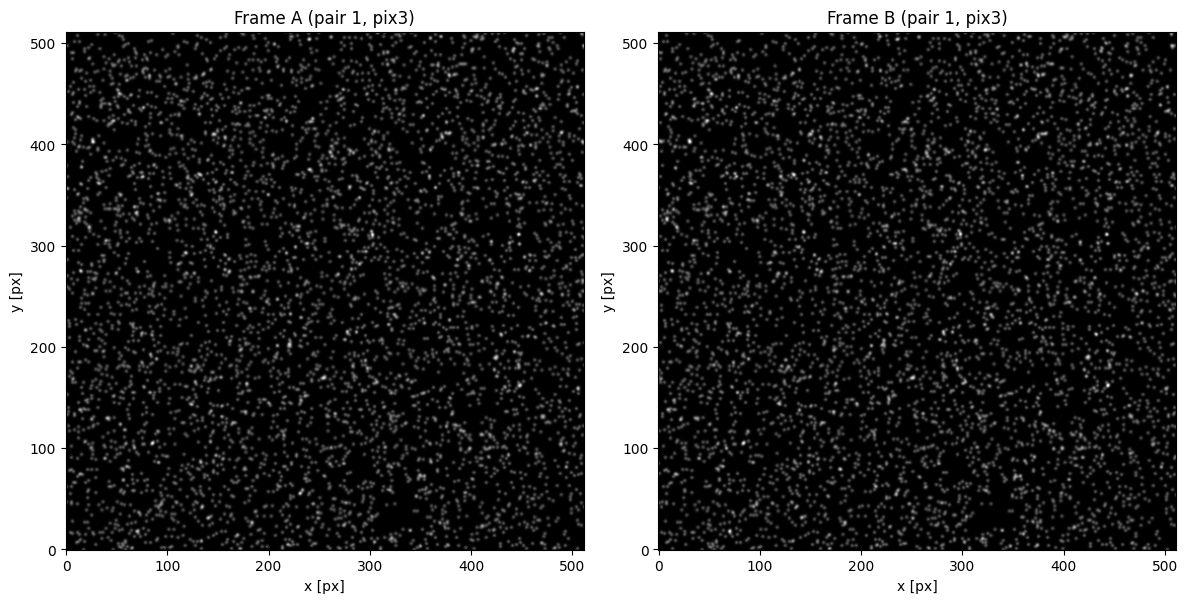

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(A, cmap='gray', origin='lower')
axes[0].set_title(f'Frame A (pair {PAIR}, pix{PIX})')
axes[1].imshow(B, cmap='gray', origin='lower')
axes[1].set_title(f'Frame B (pair {PAIR}, pix{PIX})')
for ax in axes:
    ax.set_xlabel('x [px]'); ax.set_ylabel('y [px]')
plt.tight_layout(); plt.show()

## 2. Flow components u and v

Saved in **pixels per pair** (already multiplied by Δt_pair in `ImageGenFunc.jl`), so directly comparable to displacement in the images.
* `u` (red/blue) is the x-velocity
* `v` (red/blue) is the y-velocity

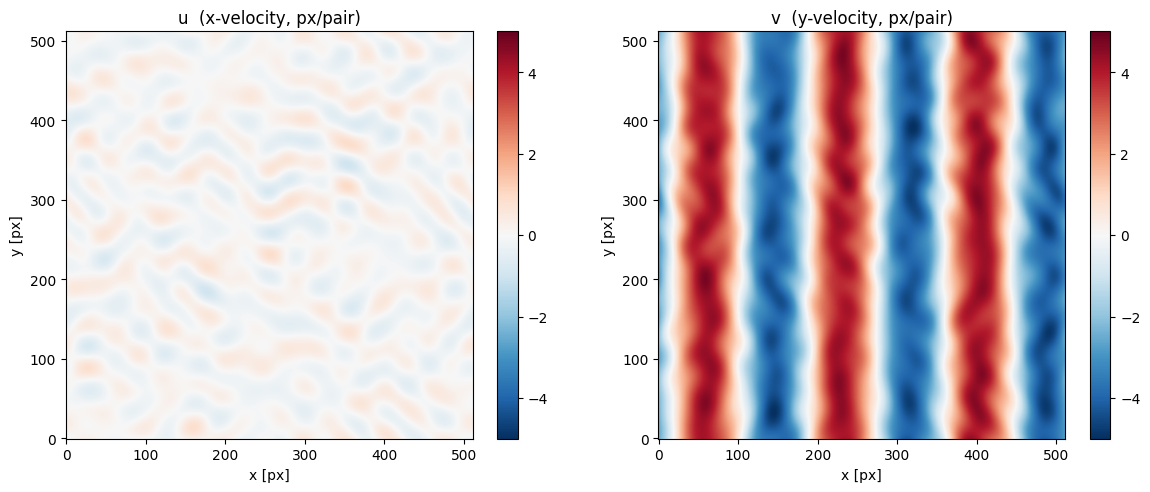

In [5]:
vmax = max(abs(uA).max(), abs(vA).max())
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
im0 = axes[0].imshow(uA, cmap='RdBu_r', vmin=-vmax, vmax=vmax, origin='lower')
axes[0].set_title('u  (x-velocity, px/pair)')
plt.colorbar(im0, ax=axes[0], fraction=0.046)
im1 = axes[1].imshow(vA, cmap='RdBu_r', vmin=-vmax, vmax=vmax, origin='lower')
axes[1].set_title('v  (y-velocity, px/pair)')
plt.colorbar(im1, ax=axes[1], fraction=0.046)
for ax in axes:
    ax.set_xlabel('x [px]'); ax.set_ylabel('y [px]')
plt.tight_layout(); plt.show()

## 3. Speed magnitude + quiver overlay

Background = `|v| = sqrt(u² + v²)`. White arrows = direction (subsampled). Most useful single view.

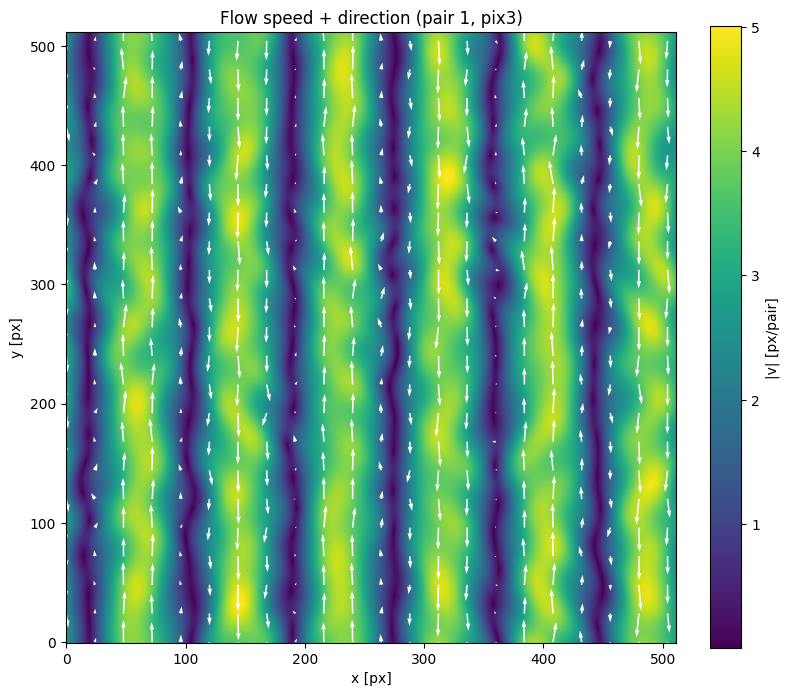

In [6]:
speed = np.hypot(uA, vA)
H, W = speed.shape
step = 24
ys, xs = np.mgrid[0:H:step, 0:W:step]
U = uA[::step, ::step]
V = vA[::step, ::step]

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(speed, cmap='viridis', origin='lower')
ax.quiver(xs, ys, U, V, color='white', scale_units='xy', angles='xy', width=0.0025)
ax.set_title(f'Flow speed + direction (pair {PAIR}, pix{PIX})')
ax.set_xlabel('x [px]'); ax.set_ylabel('y [px]')
plt.colorbar(im, ax=ax, fraction=0.046, label='|v| [px/pair]')
plt.tight_layout(); plt.show()

## 4. Displacement histograms

Sanity check on units. With `pix{N}` ImageGen *targets* ~N pixels of max displacement, but per BUG-13 this can silently fail when the simulation's save interval already produces motion bigger than N. Compare `|v| max` printed below against PIX — they should be close.

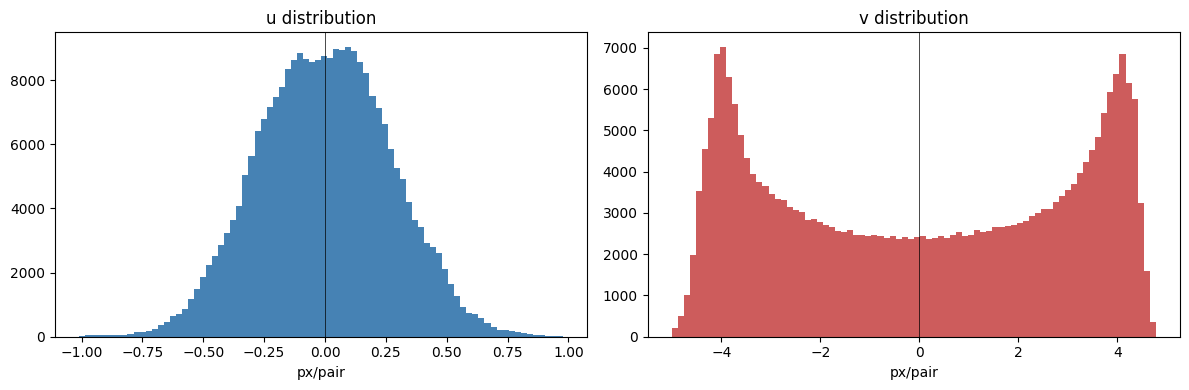

|u| max: 1.01   |v| max: 5.00   speed max: 5.00 px/pair
Target was ~3 px. If speed max >> 3, the pix3 bin is mislabeled (BUG-13).


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(uA.ravel(), bins=80, color='steelblue')
axes[0].set_title('u distribution'); axes[0].set_xlabel('px/pair')
axes[1].hist(vA.ravel(), bins=80, color='indianred')
axes[1].set_title('v distribution'); axes[1].set_xlabel('px/pair')
for ax in axes:
    ax.axvline(0, color='k', linewidth=0.5)
plt.tight_layout(); plt.show()

print(f'|u| max: {abs(uA).max():.2f}   |v| max: {abs(vA).max():.2f}   speed max: {speed.max():.2f} px/pair')
print(f'Target was ~{PIX} px. If speed max >> {PIX}, the pix{PIX} bin is mislabeled (BUG-13).')

## 5. Self-consistency check: does the flow actually agree with the particle motion?

If your data is correctly assembled, then for any small patch of the image:
* take patch from A,
* find where the same particles ended up in B (via cross-correlation),
* the displacement you measure should equal the *average flow* over that patch.

If measured and predicted disagree, either the images and fields are out of sync, the sign conventions for u/v are flipped, or the coordinate axes are transposed somewhere.

In [8]:
def fft_xcorr_peak(a, b):
    """Return integer (dy, dx) such that particles in `a` moved by (dy, dx) to land at
    the same place in `b`. Periodic FFT cross-correlation; mean-subtracted so a constant
    background doesn't dominate the peak.

    Math: cross-correlation corr[k] = sum_n a[n] * b[n+k] has the FFT identity
    corr = IFFT(conj(FFT(a)) * FFT(b)). If b[n] = a[n - d] (b is a shifted by d),
    the peak sits at k = d.
    """
    a = a.astype(np.float32) - a.mean()
    b = b.astype(np.float32) - b.mean()
    corr = np.real(np.fft.ifft2(np.conj(np.fft.fft2(a)) * np.fft.fft2(b)))
    corr = np.fft.fftshift(corr)
    H, W = corr.shape
    py, px = np.unravel_index(np.argmax(corr), corr.shape)
    return py - H // 2, px - W // 2

# Sanity test: a known shift should be recovered exactly.
rng = np.random.RandomState(0)
test_a = rng.rand(64, 64).astype(np.float32)
test_b = np.roll(test_a, shift=(2, -3), axis=(0, 1))
got = fft_xcorr_peak(test_a, test_b)
print(f'xcorr on synthetic data (expect (2, -3)): {got}')
assert got == (2, -3), 'xcorr sign convention is broken!'

xcorr on synthetic data (expect (2, -3)): (2, -3)


In [9]:
# Run the check at 9 anchor points across the image.
patch = 64
half  = patch // 2
H, W  = A.shape
anchors = [(cy, cx)
           for cy in (H // 4, H // 2, 3 * H // 4)
           for cx in (W // 4, W // 2, 3 * W // 4)]

measured = []
predicted = []
print(f'{"anchor (y, x)":>16} | {"measured (dy, dx)":>22} | {"predicted (dy, dx)":>22} | residual')
print('-' * 90)
for (cy, cx) in anchors:
    a_patch = A[cy - half:cy + half, cx - half:cx + half]
    b_patch = B[cy - half:cy + half, cx - half:cx + half]
    dy_m, dx_m = fft_xcorr_peak(a_patch, b_patch)
    dy_p = vA[cy - half:cy + half, cx - half:cx + half].mean()
    dx_p = uA[cy - half:cy + half, cx - half:cx + half].mean()
    res = np.hypot(dy_m - dy_p, dx_m - dx_p)
    measured.append((dy_m, dx_m))
    predicted.append((dy_p, dx_p))
    print(f'{(cy, cx)!s:>16} | {f"({dy_m:+d}, {dx_m:+d})":>22} | {f"({dy_p:+.2f}, {dx_p:+.2f})":>22} | {res:.2f} px')

measured  = np.array(measured,  dtype=float)
predicted = np.array(predicted, dtype=float)

   anchor (y, x) |      measured (dy, dx) |     predicted (dy, dx) | residual
------------------------------------------------------------------------------------------
      (128, 128) |               (+0, -3) |         (-2.54, -0.01) | 3.92 px
      (128, 256) |               (+0, -4) |         (+2.05, +0.03) | 4.53 px
      (128, 384) |               (+0, -3) |         (+2.60, +0.00) | 3.97 px
      (256, 128) |               (+0, +1) |         (-2.64, +0.04) | 2.81 px
      (256, 256) |               (+0, +3) |         (+2.08, +0.01) | 3.64 px
      (256, 384) |               (+0, +3) |         (+2.64, -0.02) | 4.01 px
      (384, 128) |               (+0, +3) |         (-2.68, -0.05) | 4.07 px
      (384, 256) |               (+0, +3) |         (+2.08, -0.06) | 3.70 px
      (384, 384) |               (+0, +3) |         (+2.63, -0.06) | 4.04 px


**How to read the table:** residual close to 0 means data is consistent. Cross-correlation gives integer pixel shifts, so anything below half a pixel rounding error is excellent. Residuals of 5+ px mean something is wrong (axis swap, sign flip, frame misalignment).

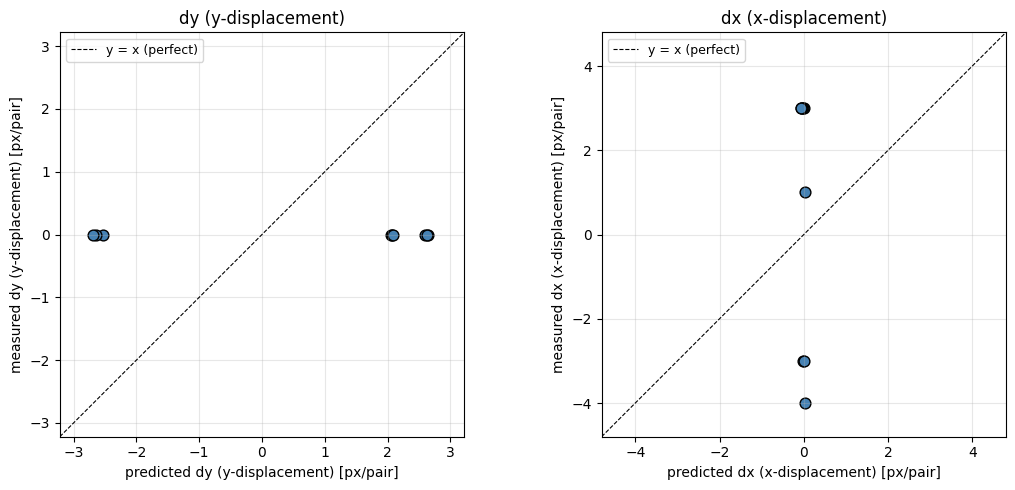

RMSE between measured and predicted displacement: 2.74 px


In [10]:
# Scatter: measured vs predicted should fall on y = x.
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for i, (name, m, p) in enumerate([('dy (y-displacement)', measured[:, 0], predicted[:, 0]),
                                   ('dx (x-displacement)', measured[:, 1], predicted[:, 1])]):
    lim = max(abs(m).max(), abs(p).max(), 1) * 1.2
    axes[i].plot([-lim, lim], [-lim, lim], 'k--', linewidth=0.8, label='y = x (perfect)')
    axes[i].scatter(p, m, s=60, color='steelblue', edgecolor='k')
    axes[i].set_xlabel(f'predicted {name} [px/pair]')
    axes[i].set_ylabel(f'measured {name} [px/pair]')
    axes[i].set_title(name)
    axes[i].set_xlim(-lim, lim); axes[i].set_ylim(-lim, lim)
    axes[i].set_aspect('equal'); axes[i].grid(alpha=0.3)
    axes[i].legend(loc='upper left', fontsize=9)
plt.tight_layout(); plt.show()

rmse = np.sqrt(((measured - predicted) ** 2).mean())
print(f'RMSE between measured and predicted displacement: {rmse:.2f} px')

**Interpretation:**
* Points clustered tightly along `y = x` → data is consistent, ML model has correct ground truth.
* Points along `y = -x` → sign convention flipped somewhere.
* Points unrelated → images and fields don't belong together (frame-index bug).
* `dy` panel mirrors `dx` panel → row/column transpose.

## 6. Cross-bin comparison: pix3 vs pix5 vs pix11

**Why this section exists (BUG-13).** ImageGen targets a max pixel displacement per bin, but if the simulation's save interval `Δt` already produces motion bigger than the target, the `dp` calculation clamps to `dp=1` and small-pix bins silently get the same data as larger ones.

**For your current sim** (`smax = 5.004 px/saved-frame`, exact):

| target `pix` | `floor(pix / 5.004)` | actual `dp` | actual max | n_pairs |
|---|---|---|---|---|
| 3  | 0 → clamp | **1** | ~5 px | 5 |
| 5  | 0 → clamp | **1** | ~5 px | 5 |
| 11 | **2** | **2** | **~10 px** | **4** |

So expect **pix3 == pix5** for the flow fields (BUG-13 manifestation), and **pix11 genuinely distinct** from both.

(Earlier I picked pix=10, but `floor(10/5.004) = 1.998` rounds down to 1 — barely missed. Pix=11 is the smallest value that actually lands on `dp=2` for this sim.)

If `data/visual/pix11/` doesn't exist yet, re-run **only** ImageGen (the slow sim is already done):
```bash
rm -rf data/visual
julia --project=. scripts/ImageGen.jl --input_dir data/binary --name verify
```

In [11]:
def load_pair(pix_bin, pair_idx):
    path = next(Path(f'data/visual/pix{pix_bin}').glob('*image_pairs*.jld2'))
    k = f'{pair_idx:06d}'
    with h5py.File(path, 'r') as f:
        g = f[f'pairs/{k}']
        return {
            'A':  g['A'][...],
            'B':  g['B'][...],
            'uA': g['fields/uA'][...],
            'vA': g['fields/vA'][...],
        }

BINS = [3, 5, 11]  # must match scripts/ImageGen.jl `pix_vals`

bins = {}
for pb in BINS:
    try:
        bins[pb] = load_pair(pb, PAIR)
        s = np.hypot(bins[pb]['uA'], bins[pb]['vA'])
        print(f'pix{pb:>2} pair {PAIR}: speed max = {s.max():.2f}  speed mean = {s.mean():.2f}  px/pair')
    except (StopIteration, FileNotFoundError, OSError, KeyError):
        bins[pb] = None
        print(f'pix{pb:>2}: not found — re-run ImageGen (see markdown above)')

if all(bins[pb] is not None for pb in BINS):
    print()
    flow_3v5   = np.array_equal(bins[3]['uA'],  bins[5]['uA'])  and np.array_equal(bins[3]['vA'],  bins[5]['vA'])
    flow_3v11  = np.array_equal(bins[3]['uA'],  bins[11]['uA']) and np.array_equal(bins[3]['vA'],  bins[11]['vA'])
    flow_5v11  = np.array_equal(bins[5]['uA'],  bins[11]['uA']) and np.array_equal(bins[5]['vA'],  bins[11]['vA'])
    print(f'pix3  == pix5  (flow)?  {flow_3v5}   ← expect True  (BUG-13)')
    print(f'pix3  == pix11 (flow)?  {flow_3v11}   ← expect False')
    print(f'pix5  == pix11 (flow)?  {flow_5v11}   ← expect False')

pix 3 pair 1: speed max = 5.00  speed mean = 2.73  px/pair
pix 5 pair 1: speed max = 5.00  speed mean = 2.73  px/pair
pix11 pair 1: speed max = 10.01  speed mean = 5.46  px/pair

pix3  == pix5  (flow)?  True   ← expect True  (BUG-13)
pix3  == pix11 (flow)?  False   ← expect False
pix5  == pix11 (flow)?  False   ← expect False


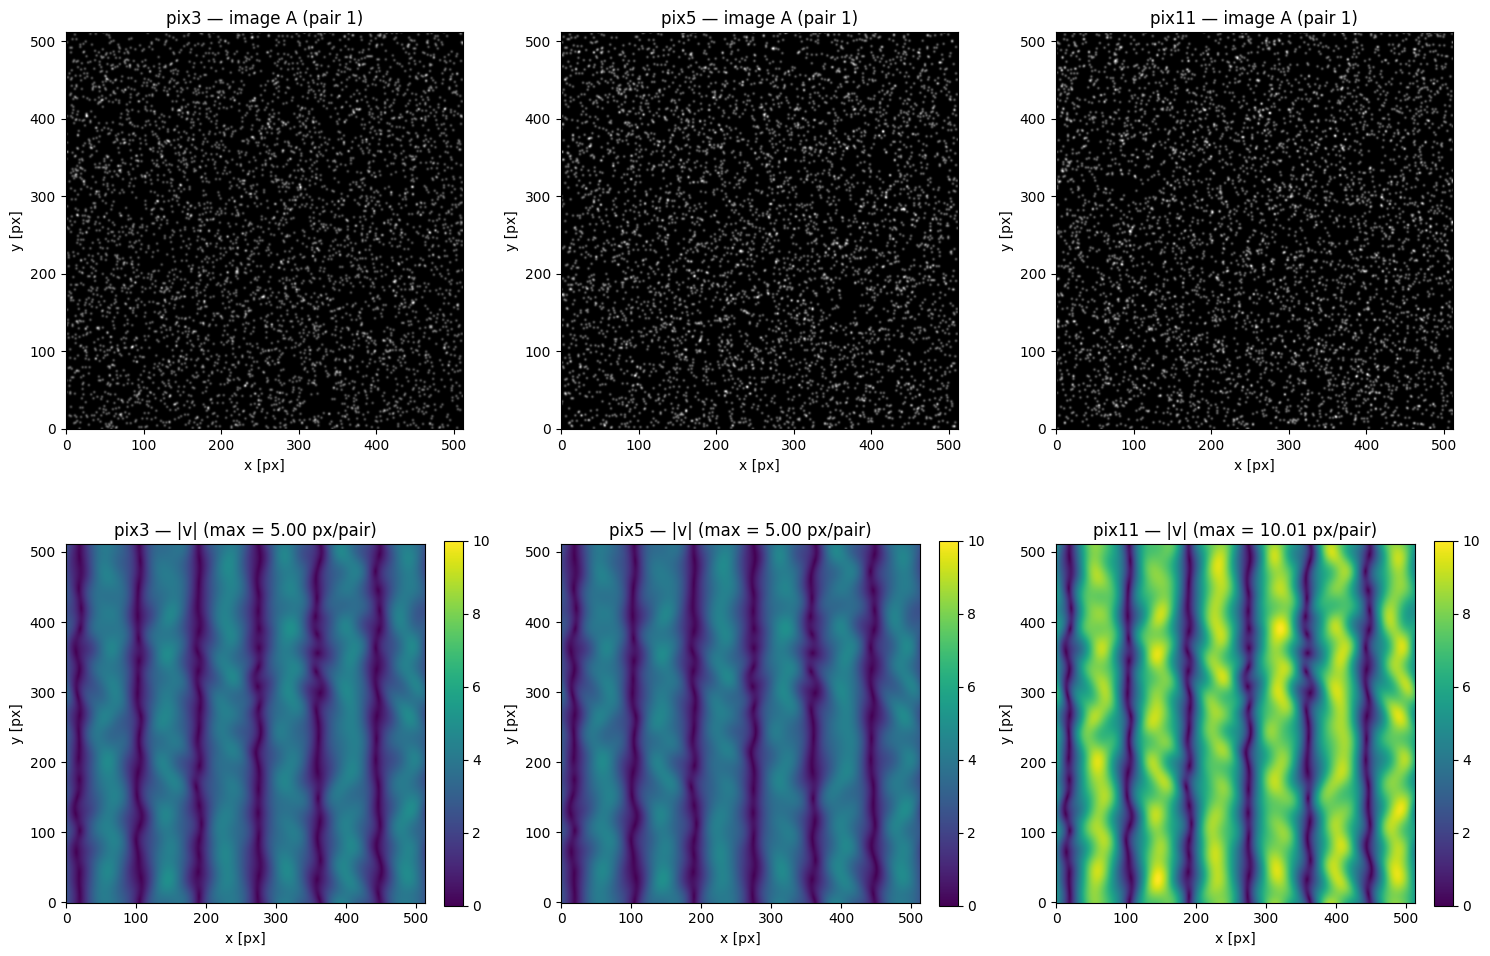

In [12]:
# 3-column grid: image A on top, speed magnitude below, one column per pix bin.
present = [pb for pb in BINS if bins[pb] is not None]
ncols = len(present)
fig, axes = plt.subplots(2, ncols, figsize=(5 * ncols, 10), squeeze=False)

speeds = {pb: np.hypot(bins[pb]['uA'], bins[pb]['vA']) for pb in present}
vmax = max(s.max() for s in speeds.values())

for i, pb in enumerate(present):
    axes[0, i].imshow(bins[pb]['A'], cmap='gray', origin='lower')
    axes[0, i].set_title(f'pix{pb} — image A (pair {PAIR})')
    im = axes[1, i].imshow(speeds[pb], cmap='viridis', vmin=0, vmax=vmax, origin='lower')
    axes[1, i].set_title(f'pix{pb} — |v| (max = {speeds[pb].max():.2f} px/pair)')
    plt.colorbar(im, ax=axes[1, i], fraction=0.046)

for ax in axes.ravel():
    ax.set_xlabel('x [px]'); ax.set_ylabel('y [px]')
plt.tight_layout(); plt.show()

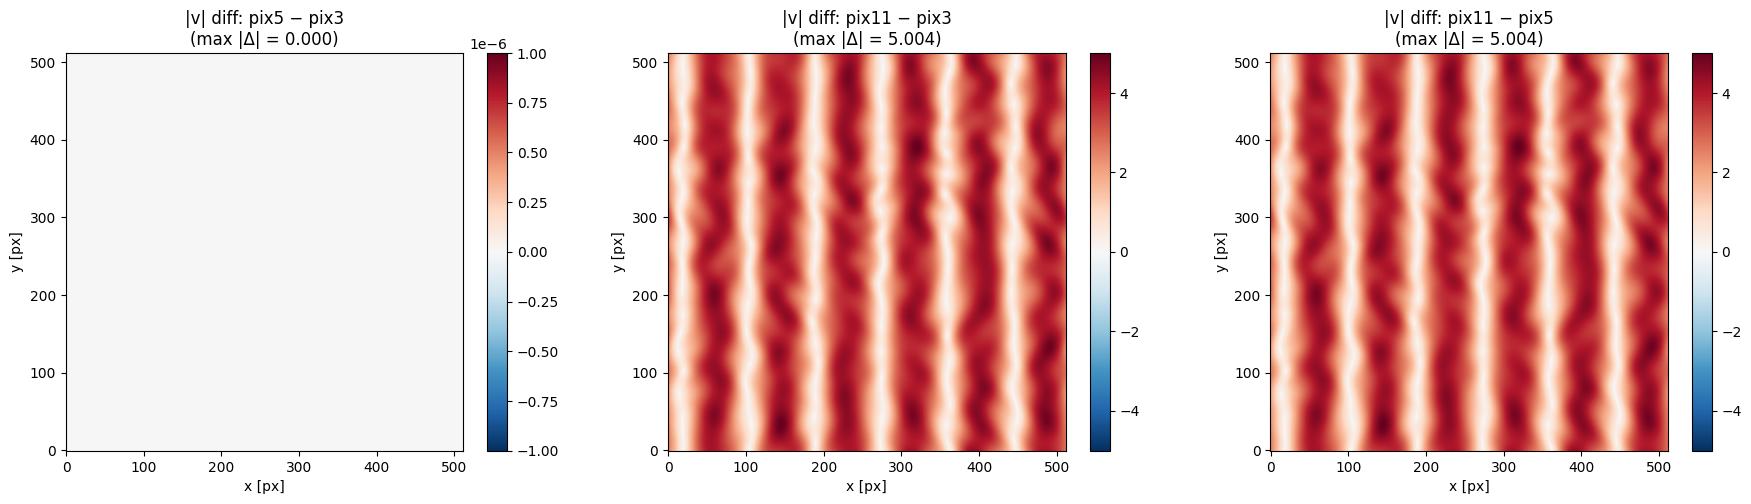

In [13]:
# Pairwise speed-difference heatmaps. All-zero (uniform color) means the bins are identical.
all_pairs = [(BINS[i], BINS[j]) for i in range(len(BINS)) for j in range(i+1, len(BINS))]
pairs_to_diff = [(a, b) for (a, b) in all_pairs if bins[a] is not None and bins[b] is not None]

fig, axes = plt.subplots(1, len(pairs_to_diff), figsize=(6 * len(pairs_to_diff), 5), squeeze=False)
for i, (a, b) in enumerate(pairs_to_diff):
    diff = speeds[b] - speeds[a]
    vlim = max(abs(diff).max(), 1e-6)
    im = axes[0, i].imshow(diff, cmap='RdBu_r', vmin=-vlim, vmax=vlim, origin='lower')
    axes[0, i].set_title(f'|v| diff: pix{b} − pix{a}\n(max |Δ| = {abs(diff).max():.3f})')
    axes[0, i].set_xlabel('x [px]'); axes[0, i].set_ylabel('y [px]')
    plt.colorbar(im, ax=axes[0, i], fraction=0.046)
plt.tight_layout(); plt.show()

## 7. Simulation diagnostics: `smax` and decorrelation

Sections 1-6 inspect one *image pair* (from `data/visual/pix*`). This section instead
reads the **combined source file** (`data/binary/*_combined.jld2`) — the raw simulation
output — to answer two design questions, mirroring `scripts/measure_smax.jl` and
`scripts/measure_decorrelation.jl` in pure Python/numpy.

- **`smax`** = the smallest particle displacement the pipeline can produce (one save
  interval of motion). It sets the *floor* for your pix bins.
- **decorrelation** = how fast the velocity field reorganizes, i.e. how many *independent*
  flow snapshots a single run actually contains.


In [14]:
# Helpers to read the combined SOURCE file (not the image-pair files used above).
# Only velocity fields (u, v) and times (t) are touched — these are plain HDF5
# datasets, so h5py reads them directly. The particle struct is never needed here.

def open_combined():
    paths = sorted(Path('data/binary').glob('*_combined.jld2'))
    if not paths:
        raise FileNotFoundError('no *_combined.jld2 in data/binary/ — run the simulation first')
    return paths[-1]   # most recent by name (timestamp-prefixed)

def frame_keys(f):
    ks = [k for k in f['fields/timeseries/u'].keys() if k != 'serialized']
    return sorted(ks, key=int)          # keys are iteration numbers as strings

def load_uv(f, k):
    u = np.squeeze(f[f'fields/timeseries/u/{k}'][...])   # (1,512,512) -> (512,512)
    v = np.squeeze(f[f'fields/timeseries/v/{k}'][...])
    return u, v

def load_t(f, k):
    return float(f[f'fields/timeseries/t/{k}'][()])

combined = open_combined()
print('Combined file:', combined.name)


Combined file: _2026-06-02T23:44:40.540_2DT-A359.766565147322-nmax21-mjet2_combined.jld2


### 7a. `smax` and the pix-bin breakdown

Reproduces `scripts/measure_smax.jl`: `smax = max(speed) * dt` from frame 1, then shows
what `dp = max(1, floor(pix/smax))` each bin gets, the actual displacement `dp*smax`, and
flags any bins that collapse onto the same `dp` (identical data — **BUG-13**).


In [15]:
PIX_VALS = [3, 5, 11]   # must match scripts/ImageGen.jl `pix_vals`

with h5py.File(combined, 'r') as f:
    ks = frame_keys(f)
    dt = load_t(f, ks[1]) - load_t(f, ks[0])
    u1, v1 = load_uv(f, ks[0])
    smax = np.hypot(u1, v1).max() * dt

print(f'frames: {len(ks)}    dt(save): {dt:.4f}')
print(f'smax (frame 1, what ImageGen uses to set dp): {smax:.3f} px  <- displacement floor')
print(f'Achievable displacements are multiples: smax, 2*smax, 3*smax, ...')
print()
print('pix   dp   actual=dp*smax   status')
print('---   --   -------------   ------')
by_dp = {}
for pix in PIX_VALS:
    dp = max(1, int(np.floor(pix / smax)))
    actual = dp * smax
    status = 'BELOW FLOOR (pix<smax: clamped, mislabeled)' if pix < smax else 'ok'
    by_dp.setdefault(dp, []).append(pix)
    print(f'{pix:<3}   {dp:<2}   {actual:<13.2f}   {status}')

collisions = {dp: b for dp, b in by_dp.items() if len(b) > 1}
if collisions:
    print('\nCOLLISIONS (identical data — BUG-13):')
    for dp, b in collisions.items():
        print(f'  dp={dp} shared by pix bins {b}')
else:
    print('\nNo collisions: every pix bin lands on a distinct dp.')


frames: 101    dt(save): 0.2742
smax (frame 1, what ImageGen uses to set dp): 4.999 px  <- displacement floor
Achievable displacements are multiples: smax, 2*smax, 3*smax, ...

pix   dp   actual=dp*smax   status
---   --   -------------   ------
3     1    5.00            BELOW FLOOR (pix<smax: clamped, mislabeled)
5     1    5.00            ok
11    2    10.00           ok

COLLISIONS (identical data — BUG-13):
  dp=1 shared by pix bins [3, 5]


### 7b. Decorrelation curve

Reproduces `scripts/measure_decorrelation.jl`, but **plots** the velocity-field
autocorrelation vs frame gap (Pearson on stacked `[u; v]`, so it measures pattern
reorganization independent of the slow energy decay). Where it crosses **1/e** is the
correlation time `tau` — the spacing at which two frames count as independent.


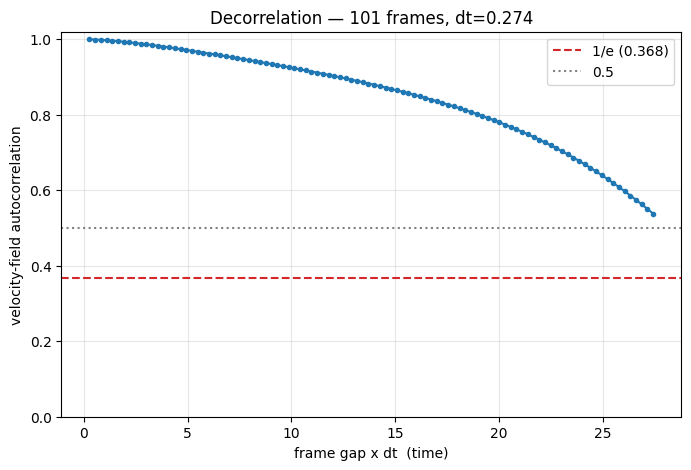

corr never drops below 1/e within 100 frames (min reached: 0.538)
-> run is shorter than one correlation time -> ~1 independent flow snapshot
-> diversity must come from MANY sims, not a longer one


In [16]:
def field_corr(uvA, uvB):
    """Pearson correlation between two flow fields, stacking u and v."""
    a = np.concatenate([uvA[0].ravel(), uvA[1].ravel()]).astype(np.float64)
    b = np.concatenate([uvB[0].ravel(), uvB[1].ravel()]).astype(np.float64)
    a -= a.mean(); b -= b.mean()
    denom = np.sqrt((a * a).sum()) * np.sqrt((b * b).sum())
    return 1.0 if denom == 0 else float((a * b).sum() / denom)

with h5py.File(combined, 'r') as f:
    ks = frame_keys(f)
    nf = len(ks)
    times = np.array([load_t(f, k) for k in ks])
    dt = (times[-1] - times[0]) / (nf - 1)
    fields = [load_uv(f, k) for k in ks]   # preload once

# autocorrelation averaged over every starting frame that admits each gap
gaps = np.arange(1, nf)
corr = np.array([np.mean([field_corr(fields[i], fields[i + g]) for i in range(nf - g)])
                 for g in gaps])

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(gaps * dt, corr, '-o', ms=3, color='tab:blue')
ax.axhline(1 / np.e, ls='--', color='tab:red',  label='1/e (0.368)')
ax.axhline(0.5,      ls=':',  color='gray',      label='0.5')
ax.set_xlabel('frame gap x dt  (time)')
ax.set_ylabel('velocity-field autocorrelation')
ax.set_title(f'Decorrelation — {nf} frames, dt={dt:.3f}')
ax.set_ylim(0, 1.02); ax.legend(); ax.grid(alpha=0.3)
plt.show()

below = np.where(corr < 1 / np.e)[0]
if below.size:
    g = int(gaps[below[0]])
    indep = max(1, (nf - 1) // g)
    print(f'tau (1/e crossing): gap {g} frames ~ {g*dt:.2f} time units')
    print(f'-> frames are ~independent every {g} saved frames')
    print(f'-> this {nf}-frame run holds ~{indep} independent snapshot(s)')
else:
    print(f'corr never drops below 1/e within {nf-1} frames (min reached: {corr.min():.3f})')
    print(f'-> run is shorter than one correlation time -> ~1 independent flow snapshot')
    print(f'-> diversity must come from MANY sims, not a longer one')
